
# Online Retail Sales: Cleaning and Exploratory Analysis

**Portfolio project: Python data cleaning and analysis** · UK-based online gift retailer · 1 Dec 2010 to 9 Dec 2011 · 541,909 transaction lines · amounts in £

**Business questions.** What really sells, and when? Where do customers come from? How concentrated is the business? And how much would careless cleaning distort the answers?

**What this notebook does differently from a first-pass analysis**

| | |
|---|---|
| **Investigates before cleaning** | Checks the extreme values and cancellation rows instead of deleting them blindly. This uncovered two huge orders cancelled minutes after being placed, plus about 2,300 postage, fee and adjustment lines mixed in with products |
| **Reusable, tested functions** | All cleaning logic lives in `src/cleaning.py` and `src/analysis.py` (with `pytest` tests), not in scattered notebook cells |
| **Measures its own impact** | Compares naive vs corrected cleaning, so you can see which decisions changed the conclusions |
| **Interprets every result** | Each chart or table is followed by what it means for the business |
| **Stage 1 maths on real data** | Dot product, variance by hand, outlier rules, conditional probability and rank correlation (Section 12) |

**To run:** put `Online Retail.xlsx` (from the UCI repository) in `data/`, then *Kernel → Restart & Run All*.


## 1. Setup

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import (NON_PRODUCT_CODES, clean_transactions, flag_rows, load_raw, standardize_types)
from src.analysis import (country_summary, customer_concentration, describe_with_skew, monthly_sales,
                          order_values, top_products, weekday_sales)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 60)
sns.set_theme(style="whitegrid", context="notebook")
GBP = mtick.FuncFormatter(lambda x, _: f"£{x:,.0f}")
GBP_K = mtick.FuncFormatter(lambda x, _: f"£{x/1000:,.0f}k")

def savefig(name):
    plt.tight_layout()
    plt.savefig(CHART_DIR / f"{name}.png", dpi=140, bbox_inches="tight")
    plt.show()

## 2. Load the raw data and take a first look

In [2]:
raw = load_raw()
print("Shape:", raw.shape)
print("Period:", raw["InvoiceDate"].min(), "->", raw["InvoiceDate"].max())
raw.head()

Shape: (541909, 8)
Period: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [3]:
quality = pd.DataFrame({"dtype": raw.dtypes.astype(str),
                        "missing": raw.isna().sum(),
                        "missing_%": raw.isna().mean() * 100,
                        "unique": raw.nunique()})
display(quality)
print(f"Exact duplicate rows : {raw.duplicated().sum():,}")
print(f"Negative quantities  : {(raw['Quantity'] < 0).sum():,}")
print(f"Zero/negative prices : {(raw['UnitPrice'] <= 0).sum():,}")

,dtype,missing,missing_%,unique
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[us],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,str,0,0.00,38


Exact duplicate rows : 5,268
Negative quantities  : 10,624
Zero/negative prices : 2,517



**First-look observations.** These are *questions to investigate*, not instructions to delete rows:

- **`CustomerID` is missing on 24.9% of rows** (135,080). That is a lot of data to throw away, so we need to know what those rows are before deciding. (The column is a float only because of the missing values.)
- **1,454 rows have no `Description`**, a negligible 0.27%.
- **5,268 rows are exact duplicates** of another row.
- **10,624 rows have a negative quantity** and **2,517 have a price of zero or less**, so not every row is a normal sale.
- The data stops on **9 Dec 2011**, so December 2011 will be a partial month.


## 3. Look before you clean

Running `dropna()` and `drop_duplicates()` on autopilot is how bad conclusions get made. Before deciding anything, investigate three suspicious things the first look hinted at: huge quantities, strange unit prices, and the cancellation rows.

In [4]:
# (a) The two largest orders in the data. What happened to them?
big = raw[raw["Quantity"].abs() >= 70_000]
big[["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,"12,346.00"
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,"12,346.00"
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,"16,446.00"
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,"16,446.00"



**Finding 1: two giant orders were cancelled minutes after being placed.**

| Order | What happened |
|---|---|
| 74,215 ceramic storage jars (£77k) | Placed 10:01, cancelled 10:17 by the same customer |
| 80,995 paper-craft items (£168k) | Placed 09:15, cancelled 09:27 by the same customer |

A cancellation row (invoice starting with `C`) only removes *itself*. If we drop the `C` rows but keep the original orders, these two phantom orders stay in the data and inflate sales and product rankings. `find_reversed_orders()` in `src/cleaning.py` matches each original order to its reversal (same customer, same product, same quantity and price, cancelled within 7 days) and removes both sides.


In [5]:
# (b) Codes that are not products. Which StockCodes are not the usual 5-digit product code?
std = flag_rows(standardize_types(raw))
non_product = (std[std["IsNonProduct"]]
               .groupby("StockCode")
               .agg(rows=("InvoiceNo", "size"), example_description=("Description", "first"),
                    max_unit_price=("UnitPrice", "max"))
               .sort_values("rows", ascending=False))
display(non_product)

print("\nHighest unit prices among normal (positive) sales lines:")
display(std[~std["IsCancellation"] & (std["Quantity"] > 0)].nlargest(5, "UnitPrice")
        [["InvoiceNo", "StockCode", "Description", "UnitPrice", "Quantity"]])

,rows,example_description,max_unit_price
StockCode,,,
POST,1256,POSTAGE,"8,142.75"
DOT,710,DOTCOM POSTAGE,"4,505.17"
M,572,Manual,"38,970.00"
C2,144,CARRIAGE,150.00
D,77,Discount,"1,867.86"
S,63,SAMPLES,570.00
BANK CHARGES,37,Bank Charges,"1,050.15"
AMAZONFEE,34,AMAZON FEE,"17,836.46"
CRUK,16,CRUK Commission,"1,100.44"



Highest unit prices among normal (positive) sales lines:


,InvoiceNo,StockCode,Description,UnitPrice,Quantity
15017,537632,AMAZONFEE,AMAZON FEE,"13,541.33",1
299982,A563185,B,Adjust bad debt,"11,062.06",1
173382,551697,POST,POSTAGE,"8,142.75",1
297723,562955,DOT,DOTCOM POSTAGE,"4,505.17",1
268028,560373,M,Manual,"4,287.63",1



**Finding 2: not every row is a product.** Codes like `POST`, `DOT` (dotcom postage), `M` (manual adjustment), `AMAZONFEE`, `BANK CHARGES` and `B` (bad-debt adjustment) are services, fees or accounting entries. They explain the "extreme prices" seen in the raw data: the highest unit price among normal sales lines is an **Amazon fee of £13,541**, followed by a bad-debt adjustment, postage and so on. These are not outliers to delete or cap, they are a *different kind of row*.

**Decision:** keep them in total sales (the money did come in) but flag them with `IsNonProduct` and exclude them from every product analysis, so postage can never again be the "best-selling product".


## 4. Clean the data (reusable functions in `src/cleaning.py`)

In [6]:
result = clean_transactions(raw)
df = result.clean
returns = result.returns
result.report

,step,rows_removed,rows_remaining,why
0,0. raw data,0,541909,starting point
1,1. exact duplicate rows,5268,536641,identical in every column: almost certainly double-logge...
2,2. cancellation rows,9251,527390,"invoice starts with 'C': money going back out, analysed ..."
3,3. non-positive quantity or price,2512,524878,"stock write-offs, free items, bad-debt adjustments: not ..."
4,4. orders fully cancelled soon after,1258,523620,"the original order of a cancelled pair (same product, or..."
5,5. flagged (kept): non-product lines,0,523620,"2,306 postage/fee/adjustment lines are flagged IsNonProd..."


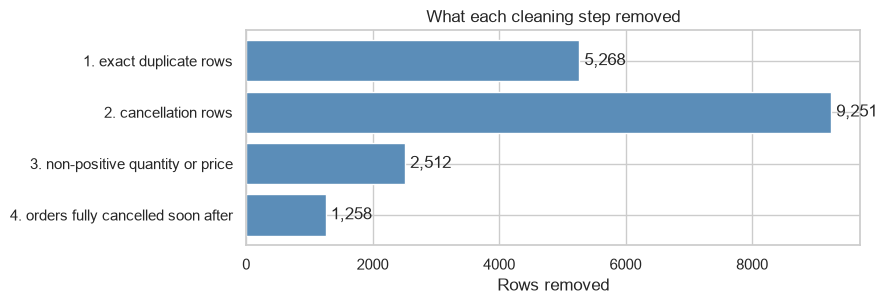

In [7]:
rep = result.report.iloc[1:5]
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(rep["step"][::-1], rep["rows_removed"][::-1], color="#5B8DB8")
for i, v in enumerate(rep["rows_removed"][::-1]):
    ax.text(v + 80, i, f"{v:,}", va="center")
ax.set_xlabel("Rows removed"); ax.set_title("What each cleaning step removed")
savefig("01_cleaning_steps")


**Cleaning decisions and why** (full audit trail in the table above):

| Step | Rows | Reason |
|---|---|---|
| Exact duplicates | −5,268 | Identical in every column, almost certainly double-logged. *(Caveat: a genuine repeat scan would also look like this, which is a small risk.)* |
| Cancellation rows | −9,251 | Money going back out. Kept in a separate `returns` table for analysis |
| Quantity ≤ 0 or price ≤ 0 | −2,512 | Stock write-offs, free items and adjustments, not real sales |
| Orders reversed soon after | −1,258 | Original side of the cancelled pairs from Finding 1 |
| Non-product lines | flagged, kept | Postage and fees are real money but not product sales |

The cleaned data keeps **523,620 rows (96.6% of the raw file)**.

**What I deliberately did *not* do**

- **Did not drop rows with a missing `CustomerID`.** They are 25% of rows but **17% of sales**: genuine sales that simply cannot be linked to a customer. They are used for sales analysis and excluded only from customer analysis.
- **Did not cap or delete big quantities.** A line of 4,800 gliders looks extreme but is a plausible wholesale order. Only rows with a *demonstrated reason* (cancelled, fee, zero price) were removed.
- **Descriptions are only labels.** Products are grouped by `StockCode` and named by their most common description, so a few missing or inconsistent descriptions do not matter.


### What did the extra cleaning change?

To see whether the extra steps were worth it, compare a **naive** cleaning (drop duplicates, drop `C` invoices, keep positive quantity and price) with the corrected pipeline.

In [8]:
def naive_clean(raw):
    d = flag_rows(standardize_types(raw)).drop_duplicates()
    d = d[~d["IsCancellation"] & (d["Quantity"] > 0) & (d["UnitPrice"] > 0)].copy()
    d["TotalSales"] = d["Quantity"] * d["UnitPrice"]
    return d

naive = naive_clean(raw)
print(f"Naive total sales    : £{naive['TotalSales'].sum():>12,.0f}")
print(f"Corrected total sales: £{df['TotalSales'].sum():>12,.0f}   "
      f"(overstated by £{naive['TotalSales'].sum() - df['TotalSales'].sum():,.0f}, "
      f"{naive['TotalSales'].sum() / df['TotalSales'].sum() - 1:.1%})")

naive_top = (naive.groupby("Description")["TotalSales"].sum().sort_values(ascending=False).head(6)
             .rename("naive sales").reset_index())
fixed_top = top_products(df, 6).reset_index(drop=True)[["Description", "sales"]].rename(columns={"sales": "corrected sales"})
pd.concat([naive_top.add_prefix("NAIVE: "), fixed_top.add_prefix("CORRECTED: ")], axis=1)

Naive total sales    : £  10,642,111
Corrected total sales: £  10,270,030   (overstated by £372,081, 3.6%)


,NAIVE: Description,NAIVE: naive sales,CORRECTED: Description,CORRECTED: corrected sales
0,DOTCOM POSTAGE,"206,248.77",REGENCY CAKESTAND 3 TIER,"172,394.64"
1,REGENCY CAKESTAND 3 TIER,"174,156.54",WHITE HANGING HEART T-LIGHT HOLDER,"105,016.33"
2,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",PARTY BUNTING,"99,385.83"
3,WHITE HANGING HEART T-LIGHT HOLDER,"106,236.72",JUMBO BAG RED RETROSPOT,"92,821.83"
4,PARTY BUNTING,"99,445.23",RABBIT NIGHT LIGHT,"66,832.59"
5,JUMBO BAG RED RETROSPOT,"94,159.81",PAPER CHAIN KIT 50'S CHRISTMAS,"64,140.94"



**Why the extra cleaning matters.** The naive approach **overstates sales by £372k (3.6%)**, and it gets the product ranking wrong in two ways:

1. **`DOTCOM POSTAGE` ranks #1**, but it is a service charge, not a product.
2. **`PAPER CRAFT, LITTLE BIRDIE` ranks #3**, with £168k from a *single order that was cancelled 12 minutes later*. (The ceramic storage jar is inflated by the same effect.)

With correct cleaning, the best-selling product is the **Regency Cakestand 3 Tier (£172k)**. The lesson is that cleaning choices are analytical choices: they change the business answer, so they need to be investigated, documented and tested.


## 5. Descriptive statistics

Money data is almost always **right-skewed**, so the mean alone can mislead. The table puts mean, median, skewness and tail percentiles side by side for four different levels of detail.

In [9]:
merch = df[~df["IsNonProduct"]]            # line-level stats: real products only (no postage / fee lines)
orders = order_values(df)                   # order value: everything on the invoice, postage included
stats = pd.DataFrame({"Quantity per line": describe_with_skew(merch["Quantity"]),
                      "Unit price (£)": describe_with_skew(merch["UnitPrice"]),
                      "Line value (£)": describe_with_skew(merch["TotalSales"]),
                      "Order value (£)": describe_with_skew(orders)}).T
stats

,count,mean,median,std,skew,p95,p99,max
Quantity per line,"521,314.00",10.30,4.00,37.61,33.77,30.00,100.00,"4,800.00"
Unit price (£),"521,314.00",3.27,2.08,4.24,20.34,9.95,16.63,649.50
Line value (£),"521,314.00",18.97,9.90,64.79,31.81,58.50,179.00,"7,144.72"
Order value (£),"19,866.00",516.97,302.92,"1,173.07",15.61,"1,571.04","4,786.99","52,940.94"


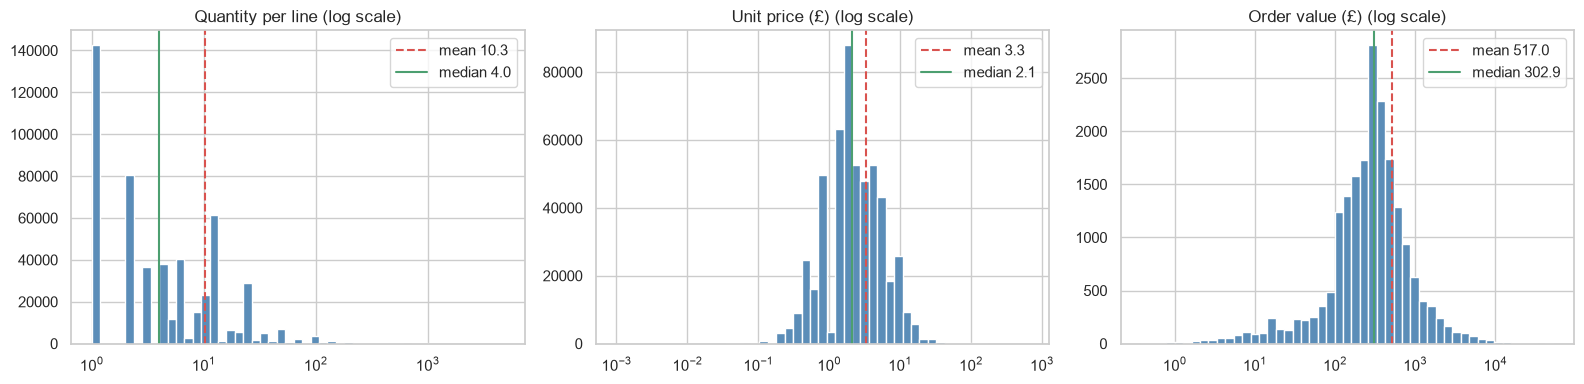

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (series, label) in zip(axes, [(merch["Quantity"], "Quantity per line"),
                                      (merch["UnitPrice"], "Unit price (£)"),
                                      (orders[orders > 0], "Order value (£)")]):
    ax.hist(series, bins=np.logspace(np.log10(series.min()), np.log10(series.max()), 50), color="#5B8DB8")
    ax.set_xscale("log")
    ax.axvline(series.mean(), color="#D9534F", ls="--", label=f"mean {series.mean():,.1f}")
    ax.axvline(series.median(), color="#4C9F70", ls="-", label=f"median {series.median():,.1f}")
    ax.set_title(label + " (log scale)"); ax.legend()
savefig("02_distributions_log_scale")


**Everything is right-skewed, so the mean alone misleads.**

- **Quantity:** median **4** units per line vs mean **10.3**. Plots on a log scale show spikes at round pack sizes (1, 2, 12, 24), a sign of how the products are packaged and sold.
- **Unit price:** median **£2.08** vs mean **£3.27**. This is a low-price gift-ware business, with a maximum real-product price of £649.50.
- **Line value:** median **£9.90** vs mean **£18.97**.
- **Order value:** a *typical* order is about **£303 (median)**, while the mean is **£517**, pulled up by a minority of very large wholesale orders (skewness 15.6, 99th percentile £4,787, maximum £52,941).

**Rule of thumb:** report the **median** for "what does a typical customer do?" and the **mean** for "how much revenue per order?" (it is the one that multiplies up to total sales). On a log scale, unit price and order value look roughly bell-shaped, which is why log transforms are so common for money data.


## 6. Sales over time

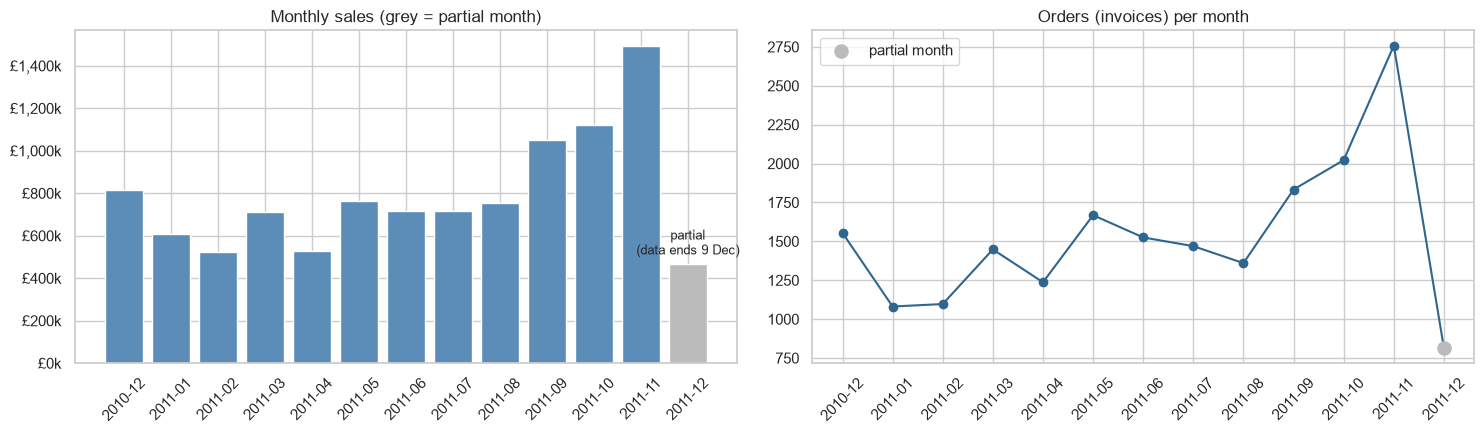

,label,sales,orders,customers,is_partial
0,2010-12,"816,277.95",1554,885,False
1,2011-01,"609,389.65",1081,740,False
2,2011-02,"521,599.86",1097,757,False
3,2011-03,"712,283.69",1448,972,False
4,2011-04,"527,425.67",1237,855,False
5,2011-05,"763,740.20",1668,1055,False
6,2011-06,"718,723.05",1525,989,False
7,2011-07,"714,855.60",1469,946,False
8,2011-08,"752,921.43",1360,935,False
9,2011-09,"1,051,089.91",1833,1264,False


In [11]:
monthly = monthly_sales(df)
monthly["label"] = monthly["Month"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
colors = np.where(monthly["is_partial"], "#BBBBBB", "#5B8DB8")
axes[0].bar(monthly["label"], monthly["sales"], color=colors, edgecolor="white")
axes[0].yaxis.set_major_formatter(GBP_K); axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Monthly sales (grey = partial month)")
partial = monthly[monthly["is_partial"]]
if len(partial):
    row = partial.iloc[0]
    axes[0].text(row["label"], row["sales"] + 25000, "partial\n(data ends 9 Dec)", ha="center", va="bottom", fontsize=9)
axes[1].plot(monthly["label"], monthly["orders"], marker="o", color="#2F6690")
axes[1].scatter(monthly.loc[monthly["is_partial"], "label"], monthly.loc[monthly["is_partial"], "orders"],
                color="#BBBBBB", s=90, zorder=3, label="partial month")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45); axes[1].set_title("Orders (invoices) per month")
savefig("03_monthly_sales")
monthly[["label", "sales", "orders", "customers", "is_partial"]]


**Reading the trend:**

- **Strong seasonality.** Sales run at about £700k to £760k a month through May to August, then climb: **£1.05M in September, £1.12M in October and £1.49M in November**, almost three times the quiet months of February and April (about £520k). The three months from September to November hold **36%** of all sales in the 13-month window. This looks like pre-Christmas stocking by retailers and wholesalers.
- **Orders, not order size, drive the peak.** Orders nearly double in November (2,758 vs roughly 1,350 to 1,700 in mid-year) while the average order value barely moves.
- **December 2011 is not a collapse.** The grey bar covers only 9 days of data, so it must not be compared with the full December 2010 (£816k).
- **Caveat:** with only one complete year, seasonality and growth cannot be separated (the November peak could partly reflect a growing business).


## 7. When do customers buy? Weekday and hour

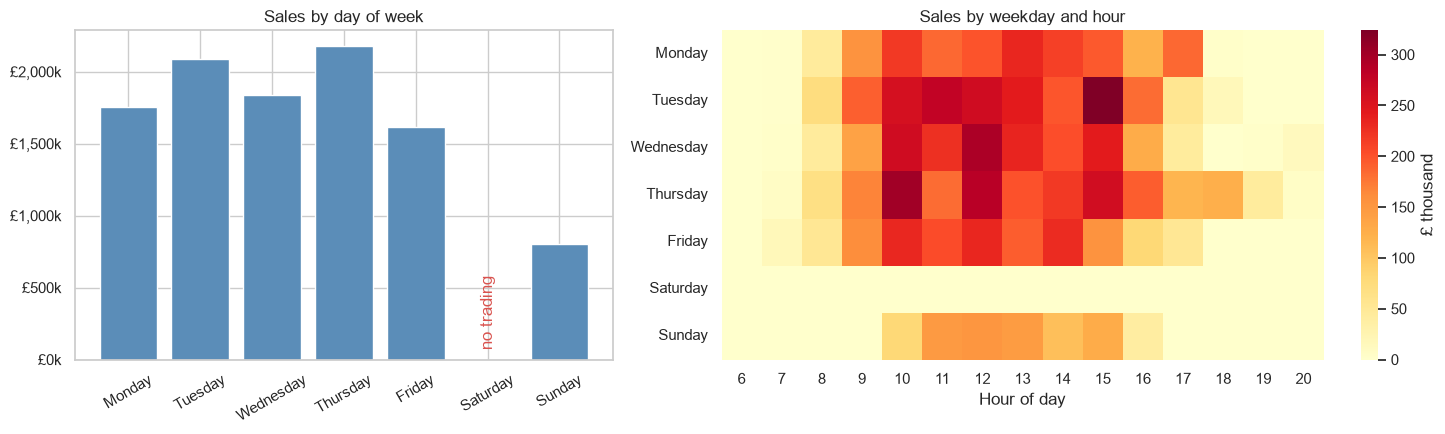

Top 3 hours by sales: {'12:00': '£1,427,340', '10:00': '£1,354,739', '15:00': '£1,307,425'}
Share of sales between 10:00 and 15:59: 75%


In [12]:
wk = weekday_sales(df)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
axes[0].bar(wk.index, wk.values, color="#5B8DB8")
axes[0].yaxis.set_major_formatter(GBP_K); axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Sales by day of week")
axes[0].text(5, wk.max() * 0.03, "no trading", ha="center", va="bottom", rotation=90, color="#D9534F")

heat = (df.pivot_table(index="DayOfWeek", columns="Hour", values="TotalSales", aggfunc="sum", fill_value=0)
          .reindex(wk.index, fill_value=0) / 1000)
sns.heatmap(heat, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "£ thousand"})
axes[1].set_title("Sales by weekday and hour"); axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("")
savefig("04_weekday_hour")

peak_hours = df.groupby("Hour")["TotalSales"].sum().sort_values(ascending=False).head(3)
print("Top 3 hours by sales:", {f"{h}:00": f"£{v:,.0f}" for h, v in peak_hours.items()})
print(f"Share of sales between 10:00 and 15:59: {df.loc[df['Hour'].between(10, 15), 'TotalSales'].sum() / df['TotalSales'].sum():.0%}")


**Trading pattern:**

- **No transactions on any Saturday** in the whole year, and Sunday is about **£0.8M vs £1.6M to £2.2M** on weekdays. Either the business does not trade on Saturdays or the data does not record them. That is a question for the data owner rather than something to assume.
- **Thursday and Tuesday are the strongest days**, and Friday is the weakest weekday.
- **Sales are concentrated around the middle of the day:** 10:00 to 15:59 accounts for **75%** of sales, with 12:00 the single busiest hour (£1.43M). Trading runs roughly 08:00 to 17:00, a little later on Thursdays, and Sundays run only about 10:00 to 16:00.
- This is a *business-hours* pattern, typical of **B2B / wholesale customers** ordering during the working day, rather than consumers shopping in the evening.


## 8. Products

,Description,sales,units,orders
StockCode,,,,
22423,REGENCY CAKESTAND 3 TIER,"172,394.64",13697,1973
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"105,016.33",37391,2261
47566,PARTY BUNTING,"99,385.83",18271,1683
85099B,JUMBO BAG RED RETROSPOT,"92,821.83",47610,2081
23084,RABBIT NIGHT LIGHT,"66,832.59",30721,992
22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,140.94",19042,1155
84879,ASSORTED COLOUR BIRD ORNAMENT,"58,905.65",36349,1453
79321,CHILLI LIGHTS,"53,767.36",10226,659
22197,POPCORN HOLDER,"51,171.77",56676,1389


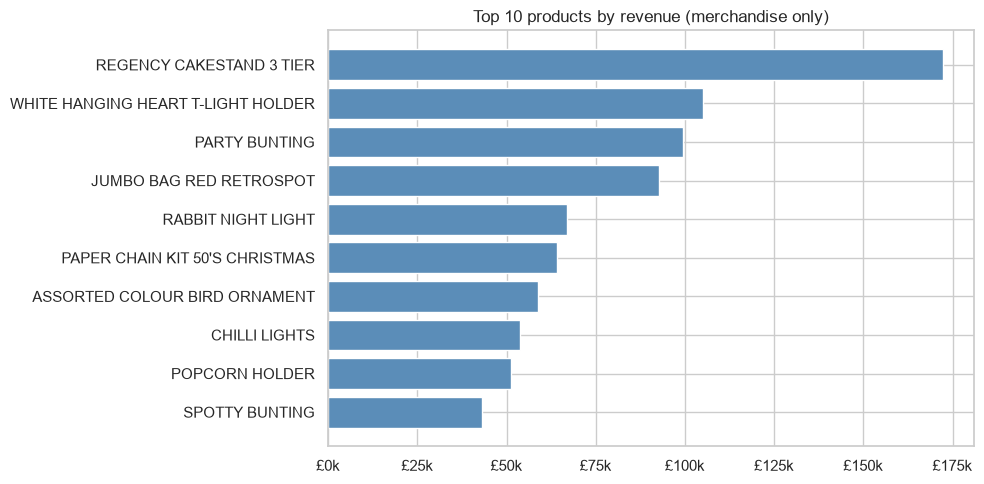

Service / fee lines excluded from the product ranking (top 6 by value):


,sales
StockCode,
DOT,"206,248.77"
POST,"77,883.88"
M,"64,267.18"
AMAZONFEE,"13,761.09"
B,"11,062.06"
C2,"7,051.00"


In [13]:
tp = top_products(df, 10)
display(tp)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(tp["Description"][::-1], tp["sales"][::-1], color="#5B8DB8")
ax.xaxis.set_major_formatter(GBP_K); ax.set_title("Top 10 products by revenue (merchandise only)")
savefig("05_top_products")

nonprod_sales = (df[df["IsNonProduct"]].groupby("StockCode")["TotalSales"].sum().sort_values(ascending=False).head(6))
print("Service / fee lines excluded from the product ranking (top 6 by value):")
display(nonprod_sales.to_frame("sales"))


**Takeaways:**

- The **Regency Cakestand 3 Tier** is the top earner (£172k from 1,973 orders), well ahead of the rest.
- **Revenue rank is not unit rank.** The cakestand sold only about 13,700 units but earns the most because each unit is expensive (about £12.60). The small popcorn holder sold the most units of the top 10 (56,676) but ranks only ninth by revenue.
- **A long tail:** the top 10 products produce only about **8%** of merchandise revenue out of nearly 3,800 products sold. No single hit product carries the business.
- Service and fee lines are separate: **£381k (3.7% of sales)**, of which dotcom postage alone is £206k.


## 9. Countries

,sales,orders,share,avg_order_value
Country,,,,
United Kingdom,"8,654,952.00",17951,0.84,482.14
Netherlands,"285,302.94",94,0.03,"3,035.14"
EIRE,"277,822.96",285,0.03,974.82
Germany,"226,675.82",454,0.02,499.29
France,"207,439.86",389,0.02,533.26
Australia,"138,114.05",54,0.01,"2,557.67"
Spain,"58,013.72",89,0.01,651.84
Switzerland,"56,886.60",53,0.01,"1,073.33"


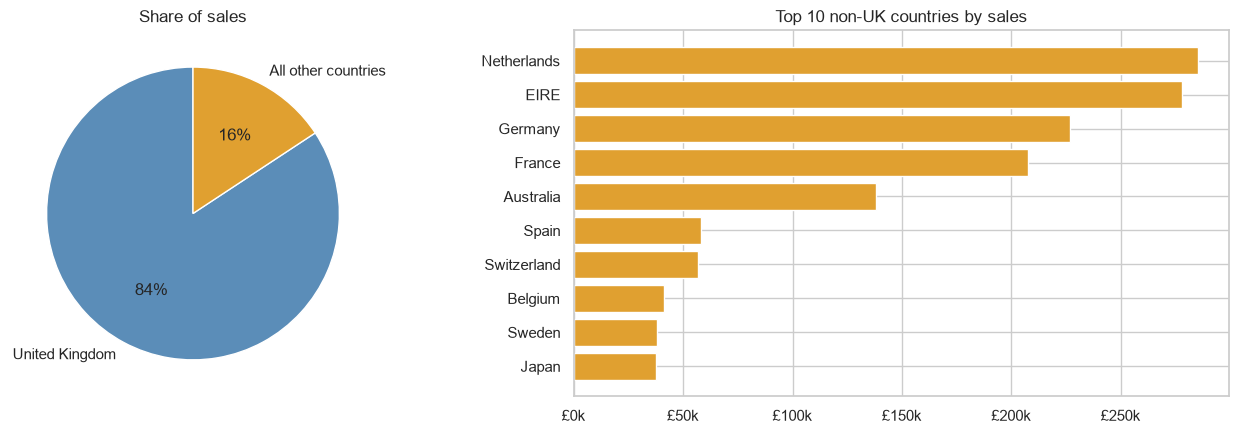

In [14]:
cs = country_summary(df)
display(cs.head(8))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].pie([cs.iloc[0]["sales"], cs.iloc[1:]["sales"].sum()], labels=["United Kingdom", "All other countries"],
            autopct="%1.0f%%", colors=["#5B8DB8", "#E0A030"], startangle=90)
axes[0].set_title("Share of sales")
export = cs.iloc[1:11]
axes[1].barh(export.index[::-1], export["sales"][::-1], color="#E0A030")
axes[1].xaxis.set_major_formatter(GBP_K); axes[1].set_title("Top 10 non-UK countries by sales")
savefig("06_countries")


**Takeaways:**

- **The UK is 84% of sales and 90% of orders.** Everything else is a small tail.
- **Some export customers behave very differently.** The Netherlands brings £285k from only **94 orders (£3,035 per order)** and Australia £138k from 54 orders (**£2,558 per order**), versus about **£482 per order** in the UK. Germany and France look like the UK (about £500 per order). That points to a few large wholesale or importer relationships.
- **Business implication:** in these markets, losing one or two accounts would visibly move the numbers, so they deserve relationship management rather than mass marketing. (The "wholesaler" reading is a hypothesis from order size; the data cannot confirm who the customers are.)


## 10. Customers

Rows with a CustomerID: 75%  |  Sales with a CustomerID: 83%


4,332 identified customers. Top 10% of customers = 60% of their sales; top 20% = 74%


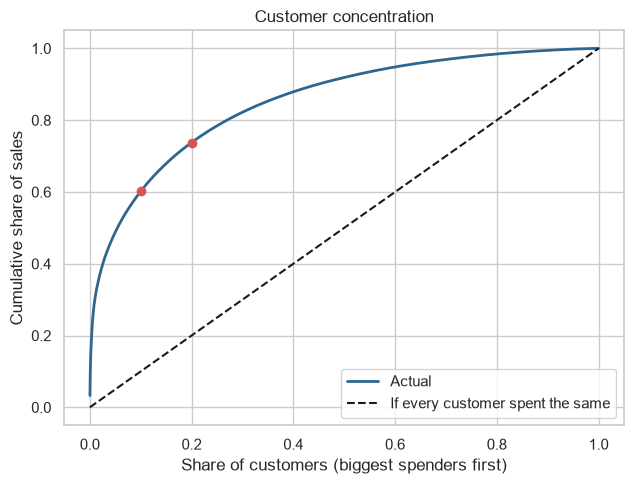

In [15]:
known_share_rows = df["HasCustomer"].mean()
known_share_sales = df.loc[df["HasCustomer"], "TotalSales"].sum() / df["TotalSales"].sum()
print(f"Rows with a CustomerID: {known_share_rows:.0%}  |  Sales with a CustomerID: {known_share_sales:.0%}")

cc = customer_concentration(df)
top10 = cc.loc[cc["customer_share"] <= 0.10, "cum_share"].iloc[-1]
top20 = cc.loc[cc["customer_share"] <= 0.20, "cum_share"].iloc[-1]
print(f"{len(cc):,} identified customers. Top 10% of customers = {top10:.0%} of their sales; top 20% = {top20:.0%}")

plt.figure(figsize=(6.5, 5))
plt.plot(cc["customer_share"], cc["cum_share"], color="#2F6690", lw=2, label="Actual")
plt.plot([0, 1], [0, 1], "k--", label="If every customer spent the same")
plt.scatter([0.1, 0.2], [top10, top20], color="#D9534F", zorder=3)
plt.xlabel("Share of customers (biggest spenders first)"); plt.ylabel("Cumulative share of sales")
plt.title("Customer concentration"); plt.legend()
savefig("07_customer_concentration")


**Takeaways:**

- **Concentration:** among the 4,332 identifiable customers, the **top 10% bring about 60% of sales and the top 20% about 74%**, close to the classic 80/20 rule. A few hundred accounts matter far more than the rest.
- **Unidentified sales are a different kind of order.** Invoices with no `CustomerID` are only 7% of invoices (1,428), but they are much bigger baskets: about **93 lines and £1,229 on average vs 21 lines and £462** for identified customers. They might be phone, trade-counter or manually keyed orders, but the data cannot say. It is worth asking, because 17% of sales cannot be tied to any customer.


## 11. Cancellations: how much money went back out?

*Definition used here:* value of all cancellation lines for real merchandise, as a share of the gross merchandise value invoiced (before any removal). It includes the two giant cancelled orders, which is exactly why they matter.

In [16]:
merch_returns = -returns.loc[~returns["IsNonProduct"], "TotalSales"].sum()
gross_merch = naive.loc[~naive["IsNonProduct"], "TotalSales"].sum()
print(f"Cancelled merchandise value : £{merch_returns:,.0f}")
print(f"Gross merchandise invoiced  : £{gross_merch:,.0f}")
print(f"Cancellations as % of gross : {merch_returns / gross_merch:.1%}")

top_returned = (returns[~returns["IsNonProduct"]].assign(value=lambda d: -d["TotalSales"])
                .groupby("Description")["value"].sum().sort_values(ascending=False).head(5))
display(top_returned.to_frame("cancelled value (£)"))

Cancelled merchandise value : £475,901
Gross merchandise invoiced  : £10,247,219
Cancellations as % of gross : 4.6%


,cancelled value (£)
Description,
"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
MEDIUM CERAMIC TOP STORAGE JAR,"77,479.64"
REGENCY CAKESTAND 3 TIER,"9,697.05"
WHITE HANGING HEART T-LIGHT HOLDER,"6,624.30"
FAIRY CAKE FLANNEL ASSORTED COLOUR,"6,591.42"



**Takeaways:**

- Cancelled merchandise is **£476k, or 4.6%** of the gross merchandise invoiced.
- But **about half of that (£246k)** is just the two giant orders from Finding 1 (£168k + £77k), which look like entry errors reversed within minutes rather than customers returning goods. Without them, ordinary cancellations are only about **2% of sales**.
- So the headline 4.6% overstates how many goods are really sent back. Context matters, and the same two orders distorted both sales *and* returns.


## 12. Stage 1 maths on real data

The roadmap asks for intuition about vectors, statistics and probability, not just Pandas. These short experiments use the same dataset.

In [17]:
# (a) Vectors and the dot product: total sales = quantity vector . price vector
q = df["Quantity"].to_numpy(dtype="float64")
p = df["UnitPrice"].to_numpy(dtype="float64")

t0 = time.perf_counter()
total_loop = 0.0
for qi, pi in zip(q.tolist(), p.tolist()):          # pure-Python loop
    total_loop += qi * pi
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
total_vec = q @ p                                    # one vectorised dot product
t_vec = time.perf_counter() - t0

print(f"Loop      : £{total_loop:,.2f}  in {t_loop*1000:7.1f} ms")
print(f"Dot product: £{total_vec:,.2f}  in {t_vec*1000:7.1f} ms   ({t_loop / t_vec:,.0f}x faster)")
print("Same answer as the TotalSales column:", np.isclose(total_vec, df["TotalSales"].sum()))

Loop      : £10,270,029.58  in   557.4 ms
Dot product: £10,270,029.58  in     2.1 ms   (260x faster)
Same answer as the TotalSales column: True


In [18]:
# (b) Variance and standard deviation from the definition
x = orders.to_numpy()
mean = x.sum() / len(x)
var_pop = ((x - mean) ** 2).sum() / len(x)               # divide by n
var_sample = ((x - mean) ** 2).sum() / (len(x) - 1)      # divide by n-1 (sample estimate)
print(f"mean {mean:,.2f} | std (n)   {np.sqrt(var_pop):,.2f} | std (n-1) {np.sqrt(var_sample):,.2f}")
print(f"np.std default (ddof=0): {np.std(x):,.2f} | pandas .std() (ddof=1): {orders.std():,.2f}")

mean 516.97 | std (n)   1,173.04 | std (n-1) 1,173.07
np.std default (ddof=0): 1,173.04 | pandas .std() (ddof=1): 1,173.07


In [19]:
# (c) Outlier rules on skewed money data: z-score vs IQR vs z-score on logs
z = (x - x.mean()) / x.std()
q1, q3 = np.percentile(x, [25, 75]); iqr = q3 - q1
lx = np.log10(x[x > 0]); lz = (lx - lx.mean()) / lx.std()
pd.DataFrame({
    "rule": ["z-score > 3 (raw)", "IQR rule 1.5x (raw)", "z-score > 3 (log10 scale)"],
    "orders flagged": [int((np.abs(z) > 3).sum()), int(((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()), int((np.abs(lz) > 3).sum())],
    "share of orders": [(np.abs(z) > 3).mean(), ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).mean(), (np.abs(lz) > 3).mean()],
}).assign(**{"share of orders": lambda d: (d["share of orders"] * 100).round(2).astype(str) + "%"})

,rule,orders flagged,share of orders
0,z-score > 3 (raw),261,1.31%
1,IQR rule 1.5x (raw),1790,9.01%
2,z-score > 3 (log10 scale),350,1.76%


In [20]:
# (d) Conditional probability: P(order > £1,000 | group)
inv = df.groupby("InvoiceNo").agg(value=("TotalSales", "sum"), lines=("StockCode", "size"),
                                  country=("Country", "first"), known=("HasCustomer", "first"))
display(inv.groupby("known").agg(invoices=("value", "size"), mean_value=("value", "mean"),
                                 median_value=("value", "median"), mean_lines=("lines", "mean"))
        .rename(index={True: "customer identified", False: "customer unidentified"}))
big = inv["value"] > 1000
rows = {"all orders": big.mean(),
        "UK": big[inv["country"] == "United Kingdom"].mean(),
        "outside UK": big[inv["country"] != "United Kingdom"].mean(),
        "customer identified": big[inv["known"]].mean(),
        "customer unidentified": big[~inv["known"]].mean()}
pd.Series(rows, name="P(order > £1,000 | ...)").to_frame().assign(**{"P(order > £1,000 | ...)": lambda d: (d.iloc[:, 0] * 100).round(1).astype(str) + "%"})

,invoices,mean_value,median_value,mean_lines
known,,,,
customer unidentified,1428,"1,228.92",465.10,92.57
customer identified,18438,461.82,302.22,21.23


,"P(order > £1,000 | ...)"
all orders,9.1%
UK,8.1%
outside UK,18.1%
customer identified,7.0%
customer unidentified,36.3%


In [21]:
# (e) Do bulk buyers get a lower price? Rank correlation is the right tool for skewed data.
rho = merch[["Quantity", "UnitPrice"]].corr(method="spearman").iloc[0, 1]
pearson = merch[["Quantity", "UnitPrice"]].corr(method="pearson").iloc[0, 1]
print(f"Pearson r  (raw)      : {pearson:+.3f}   <- dragged around by a few extreme rows")
print(f"Spearman rho (ranks)  : {rho:+.3f}")

Pearson r  (raw)      : -0.092   <- dragged around by a few extreme rows
Spearman rho (ranks)  : -0.406



**What each experiment shows**

- **(a) Vectors and the dot product.** Total sales is literally `quantity · price`. One vectorised dot product gives the identical answer to a Python loop over 520,000 rows, typically **100x or more faster**. This is why NumPy-style thinking underpins all of machine learning: a neural network layer is the same operation with a weight vector.
- **(b) Variance by hand.** Dividing by *n* vs *n−1* barely matters here (1,173.04 vs 1,173.07 across 19,866 orders) but matters a lot for small samples. A classic trap: `np.std` defaults to dividing by *n* while pandas `.std()` divides by *n−1*.
- **(c) Outlier rules disagree on skewed data.** The raw z-score flags 1.3% of orders, the IQR rule flags **9.0%** (too many to call "unusual", because it assumes a roughly symmetric distribution), and a z-score on the **log scale** flags 1.8%. Money data is multiplicative, so analysing it on a log scale is usually more sensible.
- **(d) Conditional probability.** Overall, 9.1% of orders exceed £1,000, but the probability changes with what we know: **18.1% for non-UK orders vs 8.1% for UK**, and **36.3% for orders with no customer ID vs 7.0% with one**. That is the idea behind classification models: updating a probability given features. (These are observed frequencies, not causes.)
- **(e) Pearson vs Spearman.** Pearson correlation between quantity and unit price is a negligible −0.09, but the rank-based Spearman is **−0.41**: larger quantities tend to have lower unit prices. A few extreme rows had hidden a real monotonic pattern. It could be bulk discounts *or* simply that cheap items are bought in bulk, and the data cannot separate the two.


## 13. KPIs and export

In [22]:
kpis = pd.Series({
    "Gross sales, all lines (£)": df["TotalSales"].sum(),
    "  of which merchandise (£)": merch["TotalSales"].sum(),
    "  of which postage / fees / adjustments (£)": df.loc[df["IsNonProduct"], "TotalSales"].sum(),
    "Orders (invoices)": df["InvoiceNo"].nunique(),
    "Identified customers": df["CustomerID"].nunique(),
    "Distinct products sold": merch["StockCode"].nunique(),
    "Mean order value (£)": orders.mean(),
    "Median order value (£)": orders.median(),
    "Cancellations as % of gross merchandise": merch_returns / gross_merch * 100,
})
display(kpis.to_frame("value"))

,value
"Gross sales, all lines (£)","10,270,029.58"
of which merchandise (£),"9,888,841.74"
of which postage / fees / adjustments (£),"381,187.84"
Orders (invoices),"19,866.00"
Identified customers,"4,332.00"
Distinct products sold,"3,796.00"
Mean order value (£),516.97
Median order value (£),302.92
Cancellations as % of gross merchandise,4.64


In [23]:
df.to_csv(OUTPUT_DIR / "cleaned_online_retail.csv", index=False)
result.report.to_csv(OUTPUT_DIR / "cleaning_report.csv", index=False)
kpis.to_csv(OUTPUT_DIR / "kpis.csv", header=["value"])
print("Saved:", *[p.name for p in sorted(OUTPUT_DIR.glob("*.csv"))], "+", len(list(CHART_DIR.glob('*.png'))), "charts in outputs/charts/")

Saved: cleaned_online_retail.csv cleaning_report.csv kpis.csv + 7 charts in outputs/charts/



## 14. Summary

**Key findings**

1. **The business:** £10.27M of sales (£9.89M merchandise + £0.38M postage/fees) across 19,866 orders and 4,332 identifiable customers. A typical order is about £303 (median), but the mean is £517 because of a few large wholesale orders.
2. **Data quality changed the answer.** Naive cleaning overstates sales by **£372k (3.6%)**, ranks postage as the #1 "product" and counts two orders that were cancelled within minutes.
3. **Strong Q4 seasonality:** Sep to Nov is 36% of sales; the November peak (£1.49M) comes from many more orders, not bigger ones.
4. **No hero product:** the Regency Cakestand leads (£172k), but the top 10 products make up only about 8% of merchandise revenue.
5. **The UK is 84% of sales**, but a few export customers (Netherlands, Australia) place orders 5 to 6 times larger than the typical UK order.
6. **Concentrated customers:** the top 20% of identifiable customers bring about 74% of sales.
7. **Business-hours, weekday trading:** 75% of sales fall between 10:00 and 15:59, and there are no Saturday transactions.
8. **Cancellations are about 4.6% of gross merchandise**, but about half of that is two erroneous mega-orders; ordinary cancellations are about 2%.

**Questions I would take back to the business**

- Why are there no Saturday transactions? Is it closed, or is the data incomplete?
- What are the "no customer ID" invoices (large, 93 lines on average)?
- Are the Netherlands and Australia accounts wholesalers, and who owns those relationships?

**Limitations (stated honestly)**

- **Gross sales only.** Partial returns are not netted off, and only *exact full reversals* are matched. The matching rule is a heuristic and could occasionally remove a genuine order.
- **One year of data**, with a partial final month: seasonality and growth cannot be separated.
- **Revenue, not profit:** there is no cost or margin information.
- **Exact duplicates were dropped** on the assumption that they are logging errors.

**Roadmap check (Stage 1)**

| Skill | Covered here |
|---|---|
| Load, clean, explore a dataset; reusable Python functions | Yes (`src/`, 9 tests) |
| NumPy: arrays, vectorised operations, dot product | Yes (Section 12a) |
| Pandas: filtering, missing values, groupby, merge-style joins | Yes |
| Matplotlib / reading distributions | Yes |
| Statistics and probability: mean, median, variance, conditional probability | Yes (Sections 5 and 12) |
| Linear algebra beyond the dot product, and calculus (derivatives, chain rule, gradients) | **Not here:** use 3Blue1Brown's linear algebra and calculus series, then move to Stage 2 |

**Next step (Stage 2):** turn this into a prediction problem. For example, use RFM (recency, frequency, monetary) features to segment customers or predict who will stop ordering.
